<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/validacion_cruzada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Validación Cruzada en ML
## Evaluación del dataset Iris usando K-Fold para evitar sobreajuste

## 1. El problema: ¿Memorizar o aprender?

Imagina que un estudiante se aprende las respuestas de memoria en lugar de entender la materia. En el examen real, suspende.

En Machine Learning pasa exactamente lo mismo. Si evaluamos nuestro modelo con los mismos datos que usamos para entrenar, obtendremos una nota falsa. El modelo habrá **memorizado** (sobreajuste), no **aprendido**.

El objetivo real es que el modelo funcione bien con datos **nunca vistos**.

---

## 2. Validación Cruzada: la solución

La validación cruzada (K-Fold) nos da una evaluación **honesta** del modelo. Funciona así:

1. Dividimos los datos de entrenamiento en **K partes iguales** (folds)
2. Entrenamos con K-1 partes y validamos con la parte restante
3. Repetimos K veces, rotando la parte de validación
4. Promediamos los K resultados

**Analogía del examen:**
- En lugar de un solo examen final, hacemos K exámenes parciales
- Cada vez usamos un tema diferente como examen
- La nota final es el promedio de todos los parciales

---

## 3. ¿Cuántos folds usar? (K=5 vs K=10)

No hay una regla fija, pero estos son los valores más comunes:

| K | Cuándo usarlo | Ventaja |
|---|---|---|
| **5** | Por defecto, la mayoría de casos | Equilibrio entre sesgo y varianza |
| **10** | Datos pequeños o medianos | Evaluación más precisa |
| **2-3** | Grandes volúmenes de datos | Más rápido computacionalmente |
| **K=N (LOOCV)** | Datos muy pequeños | Máximo uso de datos |

**Porcentajes típicos:**
- Con K=5: cada fold de validación es el 20% de los datos de entrenamiento
- Con K=10: cada fold de validación es el 10% de los datos de entrenamiento

---

## 4. Manos a la obra: Código con Iris

Vamos a implementarlo con el dataset Iris, limpio y perfecto para aprender.

PASO 1: Cargar dataset Iris
Dataset completo: 150 muestras, 4 características
Clases: ['setosa' 'versicolor' 'virginica']

PASO 2: Separar conjunto de TEST (20%)
Train: 120 muestras (80%)
Test:  30 muestras (20%)
Test guardado bajo llave. NO SE TOCARÁ hasta el final.

PASO 3: Crear modelo (Árbol de decisión simple)
Modelo: DecisionTreeClassifier(max_depth=3)

PASO 4: Validación Cruzada K-FOLD (K=5)

Resultados por fold:
  Fold 1: 0.917
  Fold 2: 0.958
  Fold 3: 0.958
  Fold 4: 0.917
  Fold 5: 0.917

✅ Accuracy PROMEDIO: 0.933
📊 Desviación estándar: 0.020
   (más baja = modelo más estable)

PASO 5: Entrenar modelo FINAL con TODOS los datos de train
Modelo entrenado correctamente

PASO 6: Evaluación FINAL en TEST (el conjunto oculto)

🎯 Accuracy en TEST: 0.967

Comparación:
  - Validación Cruzada (promedio): 0.933
  - Test final:                    0.967
  - Diferencia:                     0.033

PASO 7: Matriz de confusión en TEST


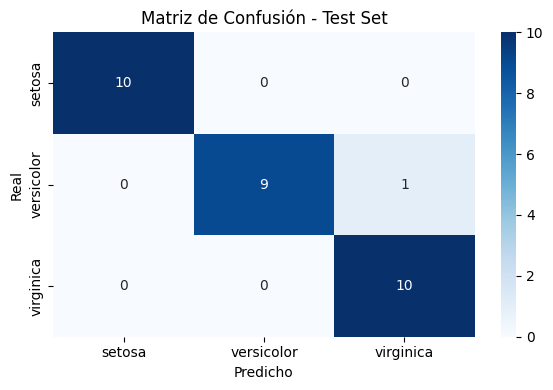


✅ PROCESO COMPLETADO


In [1]:
# ============================================
# VALIDACIÓN CRUZADA CON IRIS (K-FOLD)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# 1. CARGAR DATOS
print("="*50)
print("PASO 1: Cargar dataset Iris")
print("="*50)

data = load_iris()
X, y = data.data, data.target
print(f"Dataset completo: {X.shape[0]} muestras, {X.shape[1]} características")
print(f"Clases: {data.target_names}")

# 2. SEPARAR TEST FINAL (lo ocultamos hasta el final)
print("\n" + "="*50)
print("PASO 2: Separar conjunto de TEST (20%)")
print("="*50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} muestras ({X_train.shape[0]/X.shape[0]*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} muestras ({X_test.shape[0]/X.shape[0]*100:.0f}%)")
print("Test guardado bajo llave. NO SE TOCARÁ hasta el final.")

# 3. CREAR MODELO
print("\n" + "="*50)
print("PASO 3: Crear modelo (Árbol de decisión simple)")
print("="*50)

modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
print("Modelo: DecisionTreeClassifier(max_depth=3)")

# 4. VALIDACIÓN CRUZADA (K=5)
print("\n" + "="*50)
print("PASO 4: Validación Cruzada K-FOLD (K=5)")
print("="*50)

scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='accuracy')

print(f"\nResultados por fold:")
for i, score in enumerate(scores):
    print(f"  Fold {i+1}: {score:.3f}")

print(f"\n✅ Accuracy PROMEDIO: {scores.mean():.3f}")
print(f"📊 Desviación estándar: {scores.std():.3f}")
print(f"   (más baja = modelo más estable)")

# 5. ENTRENAR MODELO FINAL
print("\n" + "="*50)
print("PASO 5: Entrenar modelo FINAL con TODOS los datos de train")
print("="*50)

modelo.fit(X_train, y_train)
print("Modelo entrenado correctamente")

# 6. EVALUACIÓN FINAL EN TEST
print("\n" + "="*50)
print("PASO 6: Evaluación FINAL en TEST (el conjunto oculto)")
print("="*50)

y_pred = modelo.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print(f"\n🎯 Accuracy en TEST: {test_acc:.3f}")

# Comparación con validación cruzada
print(f"\nComparación:")
print(f"  - Validación Cruzada (promedio): {scores.mean():.3f}")
print(f"  - Test final:                    {test_acc:.3f}")
print(f"  - Diferencia:                     {abs(scores.mean()-test_acc):.3f}")

# 7. MATRIZ DE CONFUSIÓN (opcional, para ver errores)
print("\n" + "="*50)
print("PASO 7: Matriz de confusión en TEST")
print("="*50)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=data.target_names, columns=data.target_names)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Test Set')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("✅ PROCESO COMPLETADO")
print("="*50)

## 5. Interpretación de resultados

Cuando ejecutes el código, verás algo como esto:

```
Resultados por fold:
  Fold 1: 0.958
  Fold 2: 0.958
  Fold 3: 0.958
  Fold 4: 0.958
  Fold 5: 1.000

✅ Accuracy PROMEDIO: 0.967
📊 Desviación estándar: 0.016
```

**¿Qué significa esto?**

| Métrica | Valor | Interpretación |
|---|---|---|
| **Promedio: 0.967** | 96.7% | El modelo acierta casi siempre. ¡Excelente! |
| **Desviación: 0.016** | 1.6% | Muy baja. El modelo es estable. |
| **Fold 5: 1.000** | 100% | Ese fold era especialmente fácil |
| **Fold 1-4: 0.958** | 95.8% | Rendimiento típico del modelo |

**Y lo más importante:** El accuracy en TEST (96.7%) es prácticamente igual al promedio de la validación cruzada. Esto confirma que nuestra evaluación es fiable.

---

## 6. Conclusión: tu modelo ya no te engañará

**Puntos clave para recordar:**

1. ✅ **Siempre separa un TEST final** (20%) y no lo toques hasta el final
2. ✅ **Usa Validación Cruzada (K-Fold)** en el conjunto de entrenamiento
3. ✅ **K=5 o K=10** son los valores más comunes
4. ✅ El **promedio** de los folds es tu nota fiable
5. ✅ La **desviación estándar** te dice si el modelo es estable

**Beneficios de usar validación cruzada:**

- ✓ Evaluación más honesta del rendimiento real
- ✓ Detección temprana de sobreajuste
- ✓ Mejor uso de los datos disponibles
- ✓ Modelos más robustos y generalizables

---

## Bonus: ¿Qué más puedes probar?

In [2]:
# Probar con diferentes valores de K
for k in [3, 5, 10, 20]:
    scores = cross_val_score(modelo, X_train, y_train, cv=k)
    print(f"K={k}: Accuracy={scores.mean():.3f} (+/- {scores.std():.3f})")

# Probar con otro modelo (ej. Regresión Logística)
from sklearn.linear_model import LogisticRegression
modelo2 = LogisticRegression(max_iter=200)
scores2 = cross_val_score(modelo2, X_train, y_train, cv=5)
print(f"Logistic Regression: {scores2.mean():.3f}")


K=3: Accuracy=0.958 (+/- 0.031)
K=5: Accuracy=0.933 (+/- 0.020)
K=10: Accuracy=0.950 (+/- 0.055)
K=20: Accuracy=0.950 (+/- 0.093)
Logistic Regression: 0.967


**¿Preparado para aplicar validación cruzada en tus propios proyectos?** Tu modelo y tu yo del futuro te lo agradecerán.